### FIFA World Cup 2026: Consumer Spending Accommodations and Food SARIMA Modeling
#### Using SARIMA to forecast food & accommodation spending would look like in a normal summer (no World Cup), then measuring how much the tournament actually pushed spending above that baseline across 9 US cities.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import logging
logging.disable(logging.WARNING)
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sys
sys.path.append("..")
from constants import target_cities, host_cities, nonhost_cities

In [16]:
# Reading in data
df = pd.read_csv('../data/processed/worldcup_city_seasonal_spending.csv', index_col='Date', parse_dates=True)
df.head()

,spend_all,spend_acf,cityname,stateabbrev,city_pop2019,season,host_status
Date,,,,,,,
2022-01-31,-0.1300,-0.1580,Los Angeles,CA,10039107,Winter,Host
2022-01-31,0.1810,0.0257,Chicago,IL,5150233,Winter,Non-Host
2022-01-31,-0.0201,-0.0351,Dallas,TX,2635516,Winter,Host
2022-01-31,0.0388,0.0112,Austin,TX,1273954,Winter,Non-Host
2022-01-31,-0.0339,-0.0717,Charlotte,NC,1110356,Winter,Non-Host


Below is a pipeline test using a host city, Atlanta, to ensure the SARIMA model is functioning correctly and for debugging purposes. This test confirms that the loop-based model produces identical results to the individually fitted Atlanta model, validating the pipeline before scaling to all 9 cities.

In [17]:
# Testing SARIMA model on Atlanta to ensure pipline is working correctly

atl_df = df[df['cityname'] == 'Atlanta']
atl_spending = atl_df.spend_acf
print(atl_spending.head())
print()

# Running ADF test to check for stationarity
result = adfuller(atl_spending)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

# auto_arima model to find best parameters for SARIMA model
auto_model = auto_arima(
    atl_spending,
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    information_criterion='aic'
)

# Fit SARIMA model with best parameters found by auto_arima
sarima_model = SARIMAX(
    atl_spending,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order)
model_fit = sarima_model.fit(disp=False) 

Date
2022-01-31    0.0437
2022-02-28    0.1190
2022-03-31    0.0663
2022-04-30    0.1240
2022-05-31    0.0842
Name: spend_acf, dtype: float64

ADF Statistic: -1.1454
p-value: 0.6966


In [18]:
# Generate forecasts for the next 12 months
forecast = model_fit.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

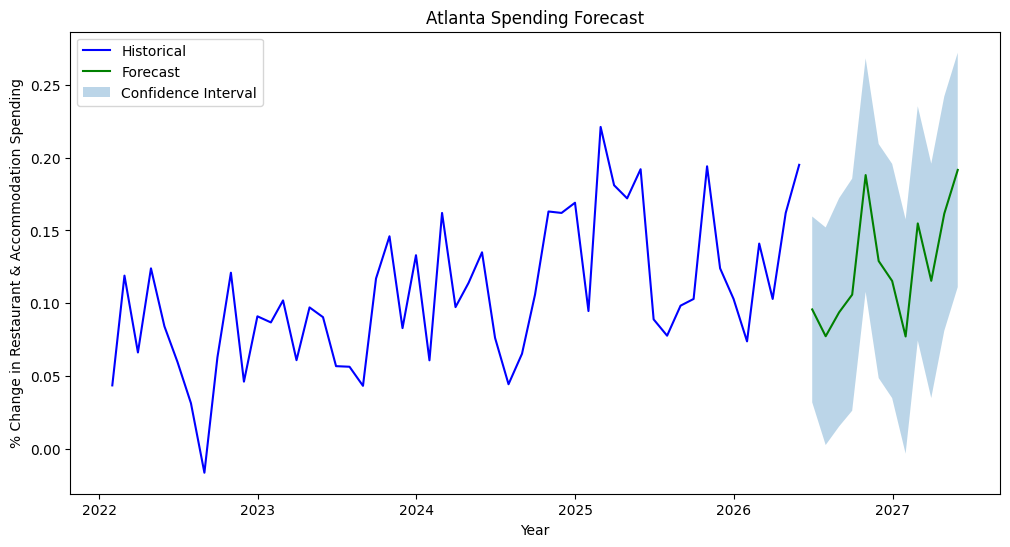

In [19]:
# Plotting Atlanta's forecasted spending trends

plt.figure(figsize=(12, 6))
plt.plot(atl_spending, label='Historical', color='blue')
plt.plot(forecast_mean, label='Forecast', color='green')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 alpha=0.3,
                 label='Confidence Interval')
plt.title("Atlanta Spending Forecast")
plt.xlabel("Year")
plt.ylabel("% Change in Restaurant & Accommodation Spending")
plt.legend()
plt.savefig('../outputs/forecasting_figures/Atlanta_forecast.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

In [20]:
# Predicting spending for all cities using SARIMA model

# Overwriting df so all cities used, not only Atlanta  
df = pd.read_csv('../data/processed/worldcup_city_seasonal_spending.csv', index_col='Date', parse_dates=True)

forecasts = {}

for city in target_cities:
    # Filter to city
    city_df = df[df['cityname'] == city]

    # Conduct ADF test to check for stationarity
    result = adfuller(city_df.spend_acf)
    print(f'ADF Statistic for {city}: {result[0]:.4f}')
    print(f'p-value for {city}: {result[1]:.4f}')

    # Run auto_arima to find best parameters for SARIMA model
    auto_model = auto_arima(
        city_df.spend_acf,
        seasonal=True,
        m=12,
        stepwise=True,
        suppress_warnings=True,
        information_criterion='aic'
    )
    
    # Fit SARIMA model with best parameters found by auto_arima
    model = SARIMAX(
        city_df.spend_acf,
        order=auto_model.order,
        seasonal_order=auto_model.seasonal_order
    )
    model_fit = model.fit(disp=False)
    
    # Generate forecast
    forecast = model_fit.get_forecast(steps=12)
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()

    # Store in forecasts dictionary
    forecasts[city] = {
        'mean': forecast_mean,
        'ci': forecast_ci,
        'historical': city_df['spend_acf']
    }

    print(f'{city} - Order: {auto_model.order}, Seasonal: {auto_model.seasonal_order}')
    print()


ADF Statistic for Los Angeles: 1.0857
p-value for Los Angeles: 0.9951
Los Angeles - Order: (1, 0, 0), Seasonal: (1, 0, 0, 12)

ADF Statistic for Denver: -1.6642
p-value for Denver: 0.4496
Denver - Order: (2, 0, 0), Seasonal: (1, 0, 0, 12)

ADF Statistic for Dallas: -1.5291
p-value for Dallas: 0.5191
Dallas - Order: (1, 1, 1), Seasonal: (1, 0, 1, 12)

ADF Statistic for Chicago: -4.2832
p-value for Chicago: 0.0005
Chicago - Order: (0, 1, 1), Seasonal: (1, 0, 1, 12)

ADF Statistic for Boston: -0.3240
p-value for Boston: 0.9220
Boston - Order: (1, 1, 1), Seasonal: (1, 0, 1, 12)

ADF Statistic for Atlanta: -1.1454
p-value for Atlanta: 0.6966
Atlanta - Order: (1, 0, 0), Seasonal: (0, 1, 1, 12)

ADF Statistic for Kansas City: 2.2995
p-value for Kansas City: 0.9990
Kansas City - Order: (1, 1, 2), Seasonal: (1, 0, 1, 12)

ADF Statistic for Austin: 1.0448
p-value for Austin: 0.9947
Austin - Order: (0, 1, 1), Seasonal: (1, 0, 0, 12)

ADF Statistic for Charlotte: -1.1282
p-value for Charlotte: 0.7

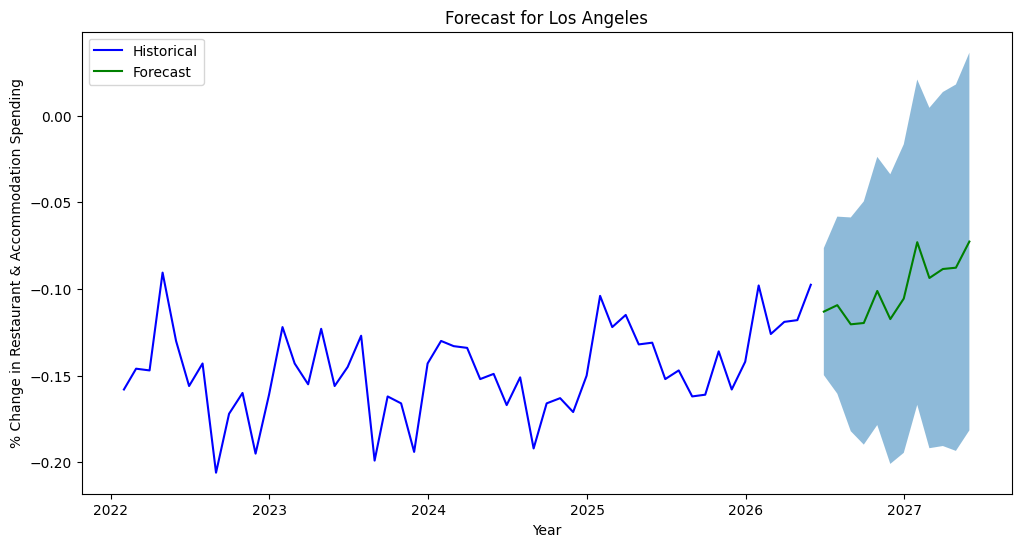

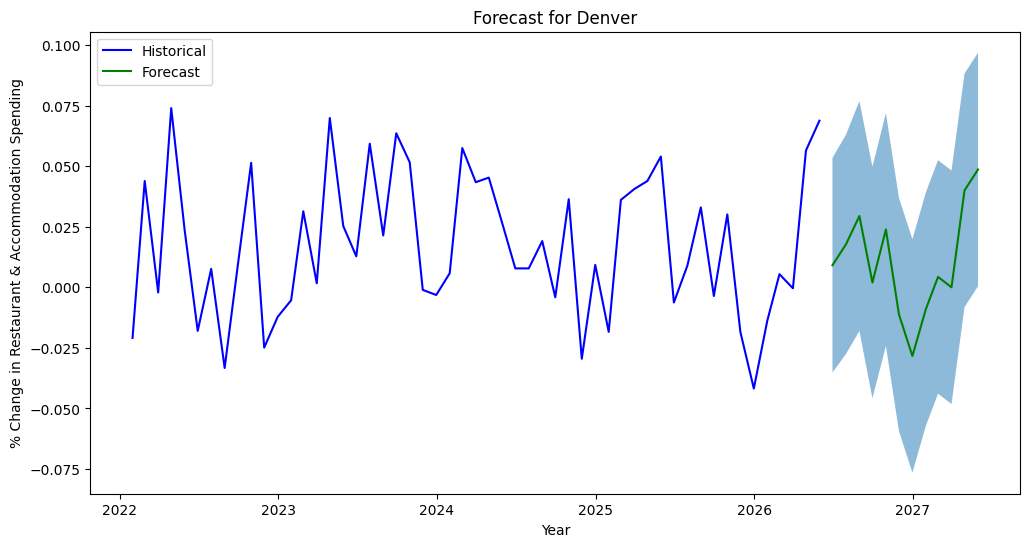

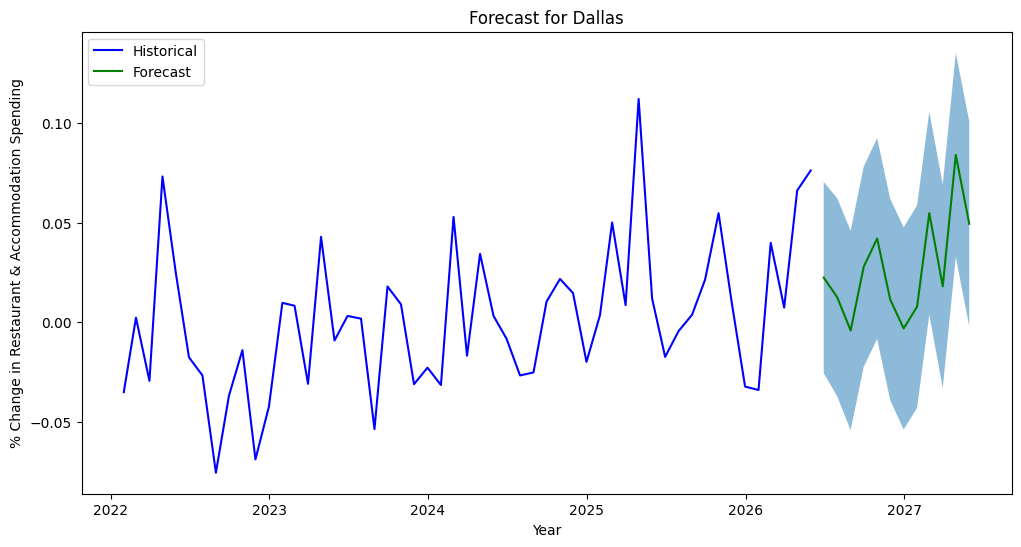

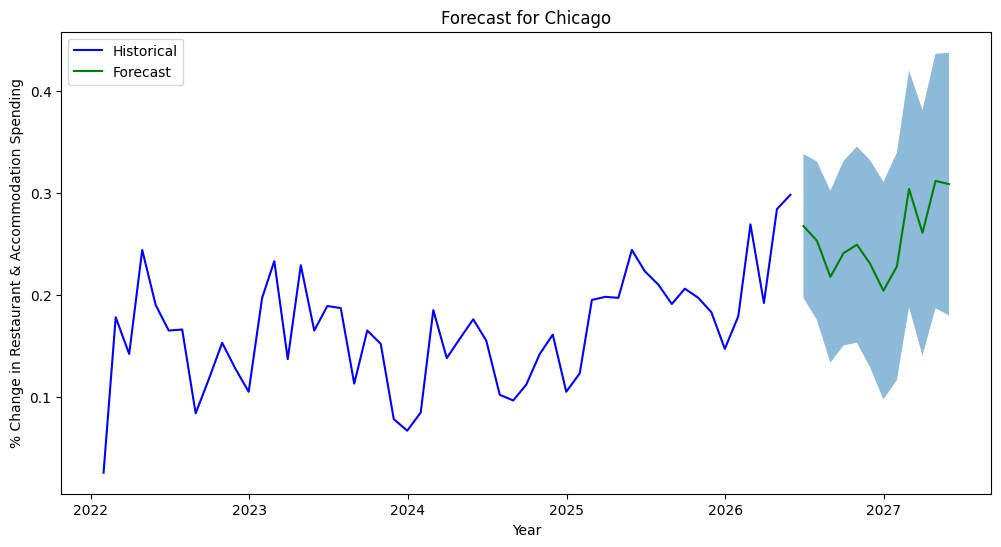

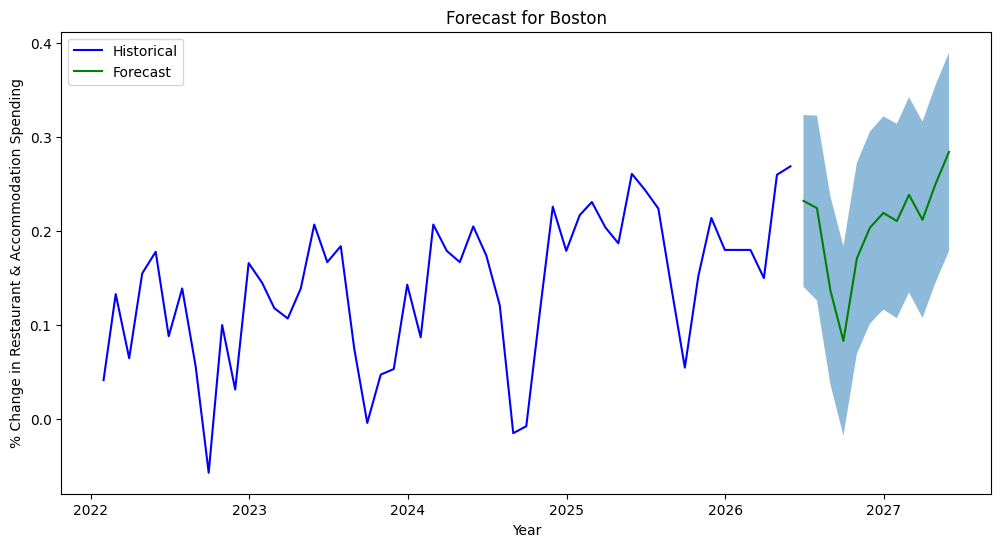

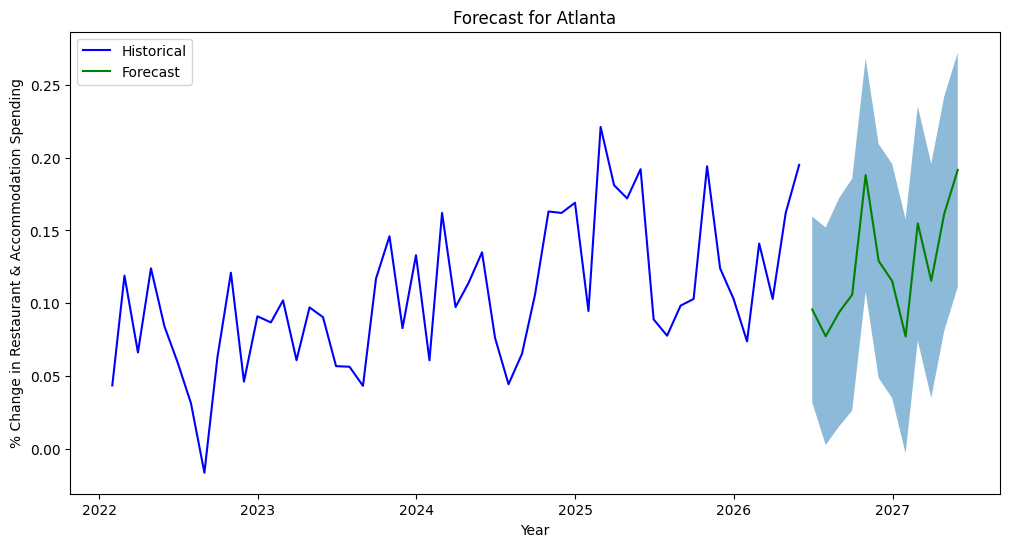

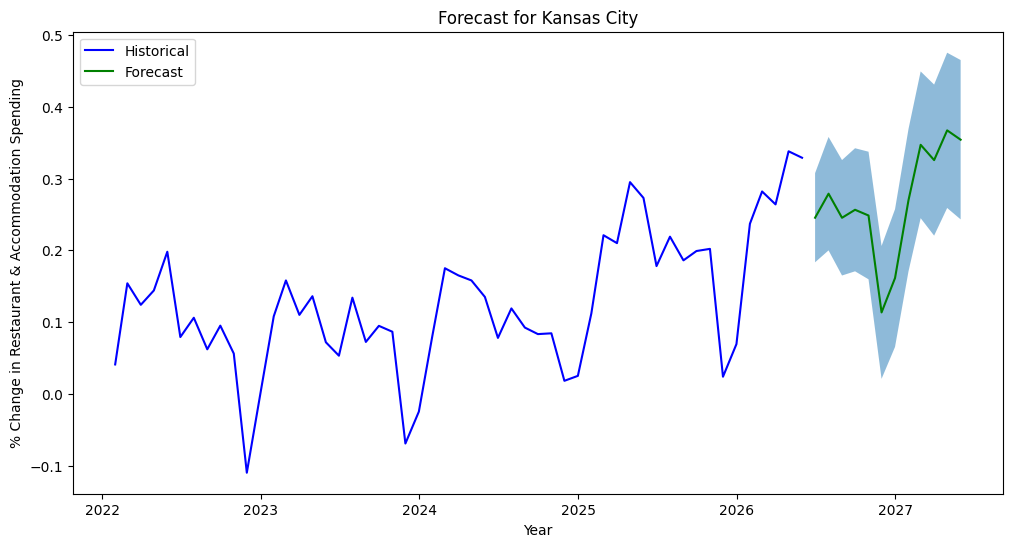

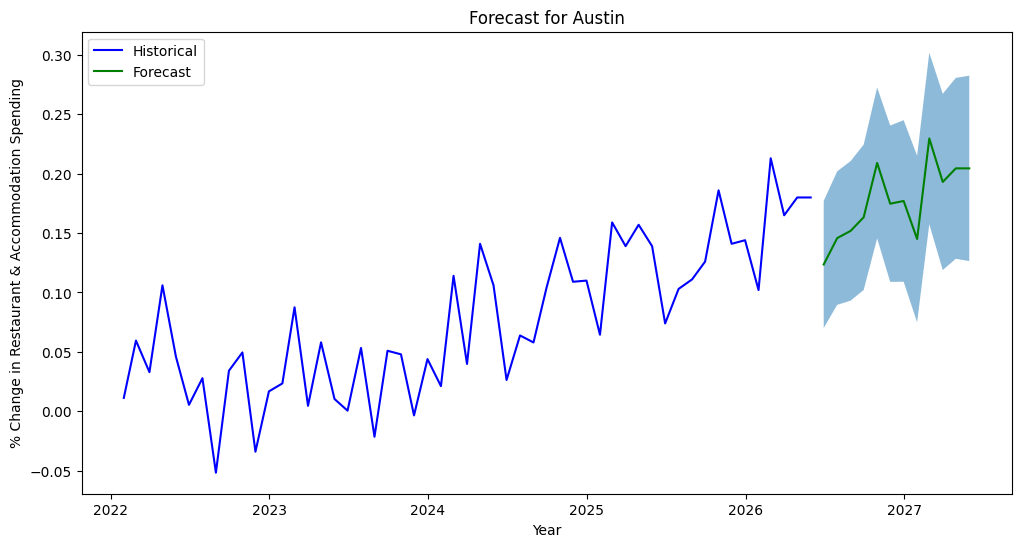

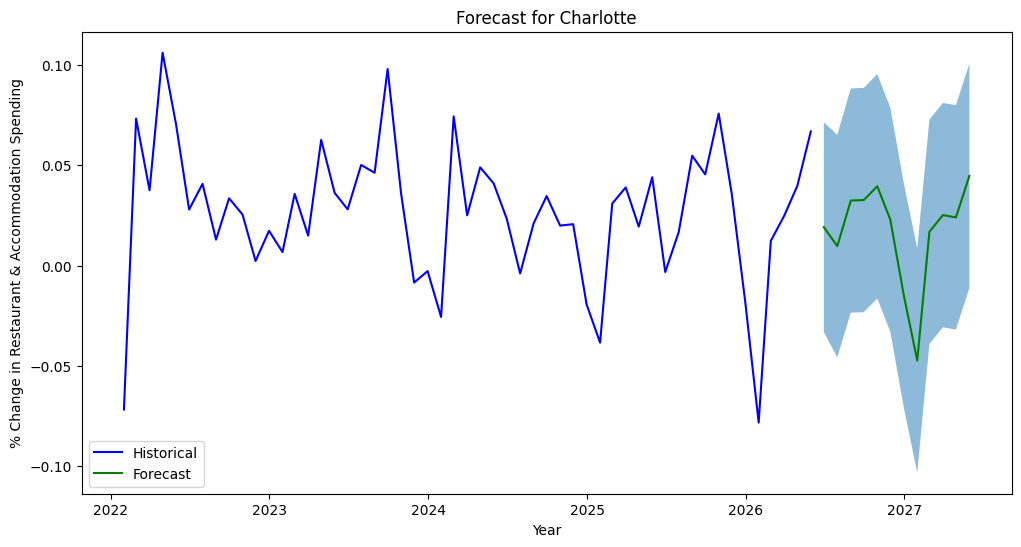

In [21]:
# Plotting the forecast for each city (baseline diff)

for city in target_cities:
    plt.figure(figsize=(12, 6))
    plt.plot(forecasts[city]['historical'], label='Historical', color='blue')
    plt.plot(forecasts[city]['mean'], label='Forecast', color='green')
    plt.fill_between(forecasts[city]['ci'].index,
                     forecasts[city]['ci'].iloc[:, 0],
                     forecasts[city]['ci'].iloc[:, 1], alpha=0.5)
    plt.title(f'Forecast for {city}')
    plt.xlabel('Year')
    plt.ylabel("% Change in Restaurant & Accommodation Spending")
    plt.legend()
    plt.savefig(f'../outputs/forecasting_figures/{city}_forecast.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

We can see Atlanta had the same graph, p-value, and ADF statistics so the SARIMA ran successfully.

Host Forecasts
            Los Angeles   Atlanta    Dallas    Boston  Kansas City
2026-06-30    -0.113078  0.095816  0.022378  0.232223     0.245399
2026-07-31    -0.109362  0.077420  0.012552  0.224539     0.278918
2026-08-31    -0.120412  0.093854 -0.004157  0.136954     0.245327
2026-09-30    -0.119650  0.105951  0.027764  0.083119     0.256483
2026-10-31    -0.101169  0.187978  0.041991  0.171059     0.248498

Non-Host Forecasts
              Denver   Chicago    Austin  Charlotte
2026-06-30  0.009121  0.267379  0.123583   0.019121
2026-07-31  0.017718  0.252982  0.145780   0.009672
2026-08-31  0.029443  0.217571  0.151882   0.032367
2026-09-30  0.001962  0.240690  0.163323   0.032634
2026-10-31  0.023889  0.249106  0.209090   0.039492


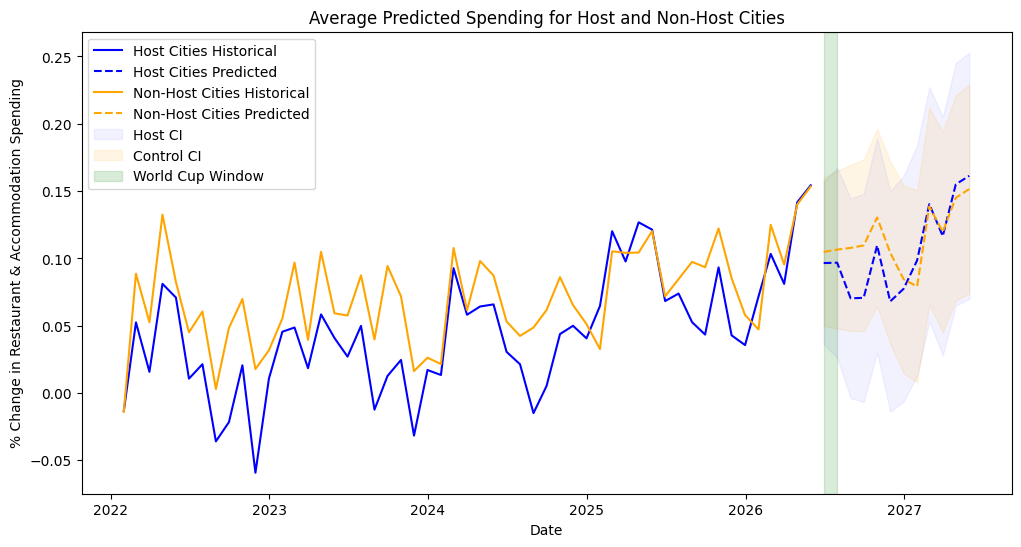

Average predicted spending for host cities in June 2026: 0.0965
Average predicted spending for non-host cities in June 2026: 0.1048
Average predicted spending for host cities in July 2026: 0.0968
Average predicted spending for non-host cities in July 2026: 0.1065


In [22]:
# Generating graph to predict summer baseline for host and non-host cities

# Dataframe of predicted mean for host cities
host_forecasts = pd.concat([forecasts[city]['mean'] for city in host_cities], axis=1)
host_forecasts.columns = host_cities
host_avg = host_forecasts.mean(axis=1) # Average spending of host cities
print("Host Forecasts")
print(host_forecasts.head())
print()

# Dataframe of predicted mean for non_host cities
nonhost_forecasts = pd.concat([forecasts[city]['mean'] for city in nonhost_cities], axis=1)
nonhost_forecasts.columns = nonhost_cities
nonhost_avg = nonhost_forecasts.mean(axis=1) # Average spending of non-host cities
print("Non-Host Forecasts")
print(nonhost_forecasts.head())

# Dataframe of historical data for host cities
host_historical = pd.concat([forecasts[city]['historical'] for city in host_cities], axis=1)
host_historical_avg = host_historical.mean(axis=1)

# Dataframe of historical data for non_host cities
nonhost_historical = pd.concat([forecasts[city]['historical'] for city in nonhost_cities], axis=1)
nonhost_historical_avg = nonhost_historical.mean(axis=1)

# Calculate confidence intervals
host_ci_lower = pd.concat([forecasts[city]['ci'].iloc[:, 0] for city in host_cities], axis=1).mean(axis=1)
host_ci_upper = pd.concat([forecasts[city]['ci'].iloc[:, 1] for city in host_cities], axis=1).mean(axis=1)

control_ci_lower = pd.concat([forecasts[city]['ci'].iloc[:, 0] for city in nonhost_cities], axis=1).mean(axis=1)
control_ci_upper = pd.concat([forecasts[city]['ci'].iloc[:, 1] for city in nonhost_cities], axis=1).mean(axis=1)

# Plotting the average predicted spending for host and non-host cities
plt.figure(figsize=(12, 6))
plt.plot(host_historical_avg, label='Host Cities Historical', color='blue')
plt.plot(host_avg, label='Host Cities Predicted', color='blue', linestyle='--')
plt.plot(nonhost_historical_avg, label='Non-Host Cities Historical', color='orange')
plt.plot(nonhost_avg, label='Non-Host Cities Predicted', color='orange', linestyle='--')
plt.fill_between(host_ci_lower.index, host_ci_lower, host_ci_upper, alpha=0.05, color='blue', label='Host CI')
plt.fill_between(control_ci_lower.index, control_ci_lower, control_ci_upper, alpha=0.1, color='orange', label='Control CI')
plt.axvspan(pd.Timestamp('2026-06-30'), pd.Timestamp('2026-07-31'), alpha=0.15, color='green', label='World Cup Window')
plt.title('Average Predicted Spending for Host and Non-Host Cities')
plt.xlabel('Date')
plt.ylabel("% Change in Restaurant & Accommodation Spending")
plt.legend()
plt.savefig('../outputs/forecasting_figures/host_nonhost_avg_forecast.png')
plt.show()


# Showing predicted baselines for host and non-host cities in during the world cup

# June predicted spending for 
avg_host_june = host_avg.loc['2026-06-30']
avg_nonhost_june = nonhost_avg.loc['2026-06-30']
print(f'Average predicted spending for host cities in June 2026: {avg_host_june:.4f}')
print(f'Average predicted spending for non-host cities in June 2026: {avg_nonhost_june:.4f}')

# July predicted spending 
avg_host_july = host_avg.loc['2026-07-31']
avg_nonhost_july = nonhost_avg.loc['2026-07-31']
print(f'Average predicted spending for host cities in July 2026: {avg_host_july:.4f}')
print(f'Average predicted spending for non-host cities in July 2026: {avg_nonhost_july:.4f}')


The chart above shows the forecasted baseline spending for host and non-host cities through mid-2027, representing what food and accommodation spending would look like in a normal summer with no World Cup influence. Non-host cities are predicted to maintain slightly higher spending than host cities, consistent with historical patterns observed in EDA, largely driven by Los Angeles underperforming other host metros.

The green shaded window marks the period where FIFA World Cup 2026 will affect consumer spending (June - July 2026). These forecast values serve as our baseline. When June and July 2026 spending data is released, the percentage point deviation from these forecasted values will quantify the World Cup spending premium for each city, directly answering how much the tournament elevated food and accommodation demand.